## Task 1: Data Loading and Initial Inspection
- Load the dataset (e.g., using pandas in Python).

- Display the first 5 rows to get a quick look at the data structure.

- Check the data types of all columns (.info()).

- Get descriptive statistics of the numerical columns (.describe()).

- Identify the total number of missing values for each column.

## Load the dataset (e.g., using pandas in Python).

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Download the dataset
!wget https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv

# Load the dataset into a pandas DataFrame
titanic_df = pd.read_csv('titanic.csv')

print("Dataset loaded successfully.")

--2026-04-13 16:37:35--  https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 60302 (59K) [text/plain]
Saving to: ‘titanic.csv.1’

titanic.csv.1       100%[===================>]  58.89K  --.-KB/s    in 0.01s   

2026-04-13 16:37:35 (4.62 MB/s) - ‘titanic.csv.1’ saved [60302/60302]

Dataset loaded successfully.


## Display the first 5 rows to get a quick look at the data structure.

In [9]:
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Check the data types of all columns (.info()).

In [10]:
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


##Get descriptive statistics of the numerical columns (.describe()).


In [11]:
titanic_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


##Identify the total number of missing values for each column.

In [12]:
titanic_df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


## Task 2: Univariate Analysis

- Univariate analysis looks at a single variable at a time.

- Survival Rate:

- Calculate the overall survival rate (percentage of passengers who survived).

- Visualize the distribution of the Survived variable (e.g., a count plot/bar chart).

- Passenger Class (Pclass):

- Visualize the distribution of Pclass using a count plot.

- Identify which class had the most passengers.

## Survival Rate
- Calculate the overall survival rate (percentage of passengers who survived).

In [15]:
survival_rate = titanic_df['Survived'].mean() * 100
print(f"Overall Survival Rate: {survival_rate:.2f}%")

Overall Survival Rate: 38.38%


## Visualize the distribution of the Survived variable (e.g., a count plot/bar chart).

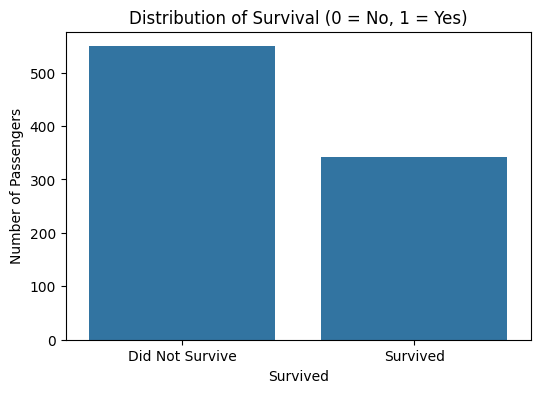

In [17]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Survived', data=titanic_df)
plt.title('Distribution of Survival (0 = No, 1 = Yes)')
plt.xlabel('Survived')
plt.ylabel('Number of Passengers')
plt.xticks(ticks=[0, 1], labels=['Did Not Survive', 'Survived'])
plt.show()

## Passenger Class (Pclass)
- Visualize the distribution of Pclass using a count plot.

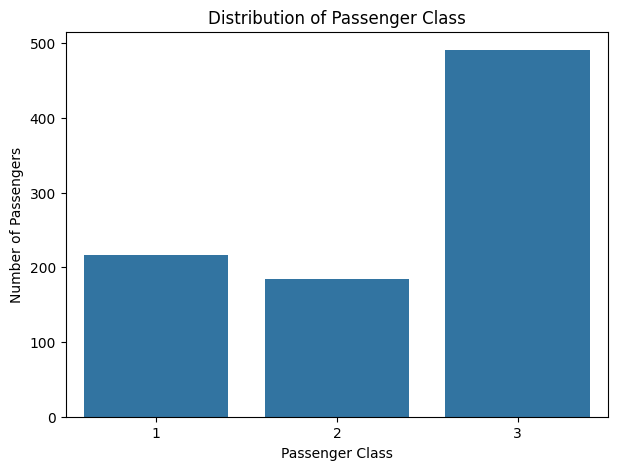

In [19]:
plt.figure(figsize=(7, 5))
sns.countplot(x='Pclass', data=titanic_df)
plt.title('Distribution of Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Number of Passengers')
plt.show()

## Identify which class had the most passengers.

In [20]:
most_passengers_pclass = titanic_df['Pclass'].value_counts().idxmax()
print(f"The passenger class with the most passengers is: {most_passengers_pclass} (Class {most_passengers_pclass})")

The passenger class with the most passengers is: 3 (Class 3)


## Task 3: Bivariate and Multivariate Analysis

- Bivariate analysis explores the relationship between two variables, specifically focusing on how other features relate to the target variable (Survived).

In [22]:
titanic_df[['Pclass', 'Survived']].groupby(['Pclass'], as_index=False).mean().sort_values(by='Survived', ascending=False)

,Pclass,Survived
0,1,0.629630
1,2,0.472826
2,3,0.242363


In [21]:
titanic_df[["Sex", "Survived"]].groupby(['Sex'], as_index=False).mean().sort_values(by='Survived', ascending=False)

,Sex,Survived
0,female,0.742038
1,male,0.188908


In [23]:
titanic_df[["SibSp", "Survived"]].groupby(['SibSp'], as_index=False).mean().sort_values(by='Survived', ascending=False)

,SibSp,Survived
1,1,0.535885
2,2,0.464286
0,0,0.345395
3,3,0.250000
4,4,0.166667
5,5,0.000000
6,8,0.000000


In [24]:
titanic_df[["Parch", "Survived"]].groupby(['Parch'], as_index=False).mean().sort_values(by='Survived', ascending=False)

,Parch,Survived
3,3,0.600000
1,1,0.550847
2,2,0.500000
0,0,0.343658
5,5,0.200000
4,4,0.000000
6,6,0.000000


## Survival by Sex
- Create a crosstabulation (or a grouped count) to show the count of survivors and non-survivors grouped by Sex.

In [27]:
survival_by_sex = pd.crosstab(titanic_df['Sex'], titanic_df['Survived'])
print(survival_by_sex)

Survived    0    1
Sex               
female     81  233
male      468  109


- Visualize this relationship using a stacked bar chart or a grouped count plot.

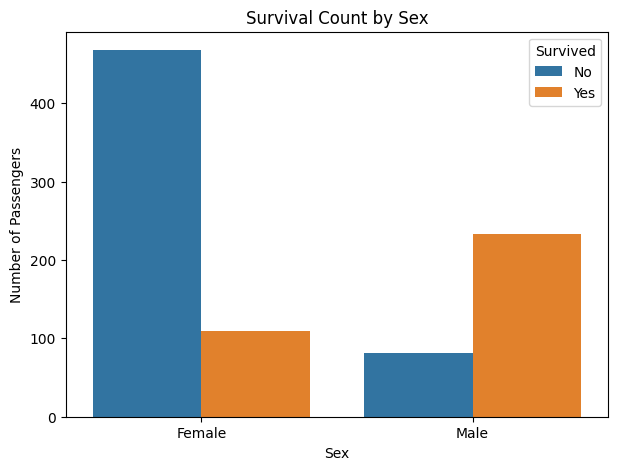

In [28]:
plt.figure(figsize=(7, 5))
sns.countplot(x='Sex', hue='Survived', data=titanic_df)
plt.title('Survival Count by Sex')
plt.xlabel('Sex')
plt.ylabel('Number of Passengers')
plt.xticks(ticks=[0, 1], labels=['Female', 'Male'])
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.show()

## Question: Which gender had a significantly higher survival rate?

In [30]:
survival_rate_by_sex = titanic_df.groupby('Sex')['Survived'].mean() * 100
print(survival_rate_by_sex)

if survival_rate_by_sex['female'] > survival_rate_by_sex['male']:
    print("\nFemale passengers had a significantly higher survival rate.")
else:
    print("\nMale passengers had a significantly higher survival rate.")

Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64

Female passengers had a significantly higher survival rate.


## Survival by Class (Pclass):

- Calculate and visualize the survival rate for each Pclass.

Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64


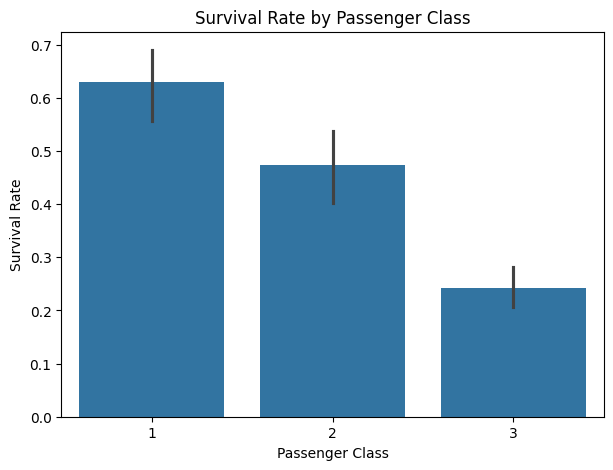

In [31]:
survival_rate_by_pclass = titanic_df.groupby('Pclass')['Survived'].mean() * 100
print(survival_rate_by_pclass)

plt.figure(figsize=(7, 5))
sns.barplot(x='Pclass', y='Survived', data=titanic_df)
plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.show()

## Question: Is there a clear correlation between ticket class and survival probability?

- Yes, there is a clear correlation between ticket class and survival probability. Passengers in First Class (Pclass 1) had the highest survival rate (62.96%), significantly higher than those in Second Class (47.28%) and Third Class (24.24%). This suggests that a higher ticket class was strongly associated with a greater chance of survival.

## Survival by Age
- Plot and compare the age distribution of survivors vs. non-survivors.

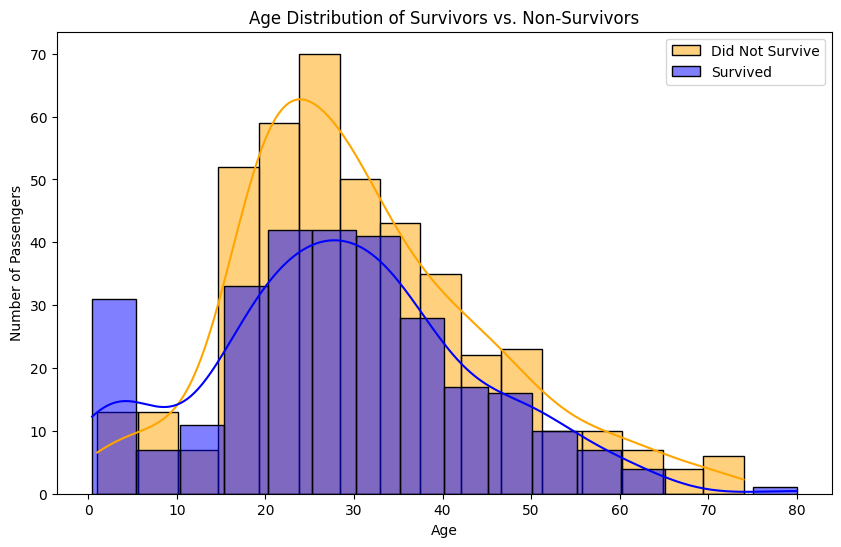

In [34]:
plt.figure(figsize=(10, 6))
sns.histplot(titanic_df[titanic_df['Survived'] == 0]['Age'].dropna(), color='orange', label='Did Not Survive', kde=True)
sns.histplot(titanic_df[titanic_df['Survived'] == 1]['Age'].dropna(), color='blue', label='Survived', kde=True)
plt.title('Age Distribution of Survivors vs. Non-Survivors')
plt.xlabel('Age')
plt.ylabel('Number of Passengers')
plt.legend()
plt.show()

## Observation: What does the plot suggest about the survival chances of children and the elderly?

- The plot suggests that **children (very young ages)** had a higher chance of survival, as evidenced by a prominent peak in the **'Survived' (blue)** distribution within the lower age ranges. For the **elderly**, while not as distinct as for children, there is still representation in the 'Survived' group, implying some older individuals did survive, though the peak is less pronounced than for younger ages.

## Survival by Port of Embarkation (Embarked):

- Calculate and visualize the survival rate for each Embarked port.

Embarked
C    55.357143
Q    38.961039
S    33.695652
Name: Survived, dtype: float64


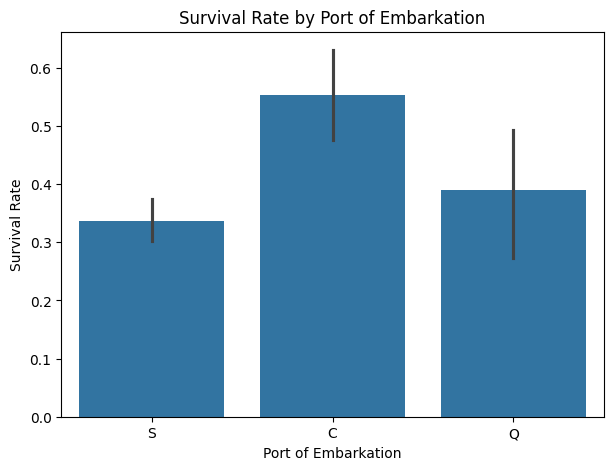

In [36]:
survival_rate_by_embarked = titanic_df.groupby('Embarked')['Survived'].mean() * 100
print(survival_rate_by_embarked)

plt.figure(figsize=(7, 5))
sns.barplot(x='Embarked', y='Survived', data=titanic_df)
plt.title('Survival Rate by Port of Embarkation')
plt.xlabel('Port of Embarkation')
plt.ylabel('Survival Rate')
plt.show()

## Task 4: Conclusion and Insights

- Based on your EDA, write a brief (3-5 sentences) conclusion summarizing the most significant factors affecting survival on the Titanic. Highlight the top 2-3 features that appear to be the strongest predictors of survival.

- The Exploratory Data Analysis reveals that survival on the Titanic was significantly influenced by several key factors. **Sex** emerged as the strongest predictor, with females having a substantially higher survival rate compared to males. **Passenger Class (Pclass)** also played a crucial role, as passengers in higher classes (1st and 2nd) had markedly better survival probabilities than those in 3rd class. Additionally, **Age** appeared to be a contributing factor, with younger children showing a higher chance of survival. Therefore, the top two strongest predictors of survival were undeniably **Sex** and **Pclass**.